# Scheme Success Model

This matches how the project doc actually describes it - given the scheme inputs
(location, price, plot size, amenities, distance from metro, ad budget), predict
**all** of: Expected_Leads, Expected_Bookings, Estimated_Conversion_Pct AND
Scheme_Success_Score together. These four are the "outputs" - not something you'd
already know before proposing the scheme, so none of them go in as features anymore,
only the real inputs do.

Two parts:
1. **Regression** - multi-output, predicts all 4 numbers at once
2. **Classification** - predicts Demand_Level (HIGH/MEDIUM/LOW) from the same real inputs


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               RandomForestClassifier, GradientBoostingClassifier)
from sklearn.metrics import (mean_absolute_error, r2_score, accuracy_score,
                              confusion_matrix, classification_report)

df = pd.read_csv("../data/raw/historical_scheme_data.csv")
print(df.shape)
df.head()


(800, 16)


,Scheme_ID,Location,Plot_Size_SqFt,Price_INR,Monthly_EMI_INR,Park,Clubhouse,Distance_from_Metro_km,Advertising_Budget_INR,Expected_Leads,Expected_Bookings,Estimated_Conversion_Pct,Demand_Level,Scheme_Success_Score,Target_Age_Group,Most_Likely_Buyers
0,SCH_0101,Delhi (Outer/Bawana),800,1320000,9200,Yes,No,3.9,1500000,3230,602,18.6,HIGH,79,25-38,First-time Buyers & Investors
1,SCH_0102,Gurugram (SPR/Sohna),1800,8270000,57400,Yes,Yes,16.2,1500000,2335,348,14.9,HIGH,79,40-60,Affluent Investors & Luxury Homes
2,SCH_0103,Kolkata (New Town/Rajarhat),1500,3030000,21000,Yes,No,5.5,750000,1267,227,17.9,MEDIUM,74,25-38,First-time Buyers & Investors
3,SCH_0104,Bengaluru (North),1000,6360000,44200,Yes,No,23.9,1000000,1015,99,9.8,LOW,41,32-48,Self-use (Villa) + Investment
4,SCH_0105,Greater Noida,2400,8150000,56600,No,No,23.4,1000000,1180,73,6.2,LOW,25,40-60,Affluent Investors & Luxury Homes


## quick eda

In [2]:
df[["Expected_Leads", "Expected_Bookings", "Estimated_Conversion_Pct", "Scheme_Success_Score"]].describe()


,Expected_Leads,Expected_Bookings,Estimated_Conversion_Pct,Scheme_Success_Score
count,800.000000,800.000000,800.000000,800.000000
mean,1221.776250,174.640000,13.825500,57.352500
std,882.878693,148.187034,3.497759,17.067656
min,102.000000,7.000000,5.700000,20.000000
25%,475.000000,62.750000,11.300000,44.000000
50%,985.500000,133.500000,13.650000,58.000000
75%,1796.750000,244.250000,16.100000,71.000000
max,4667.000000,1046.000000,25.200000,98.000000


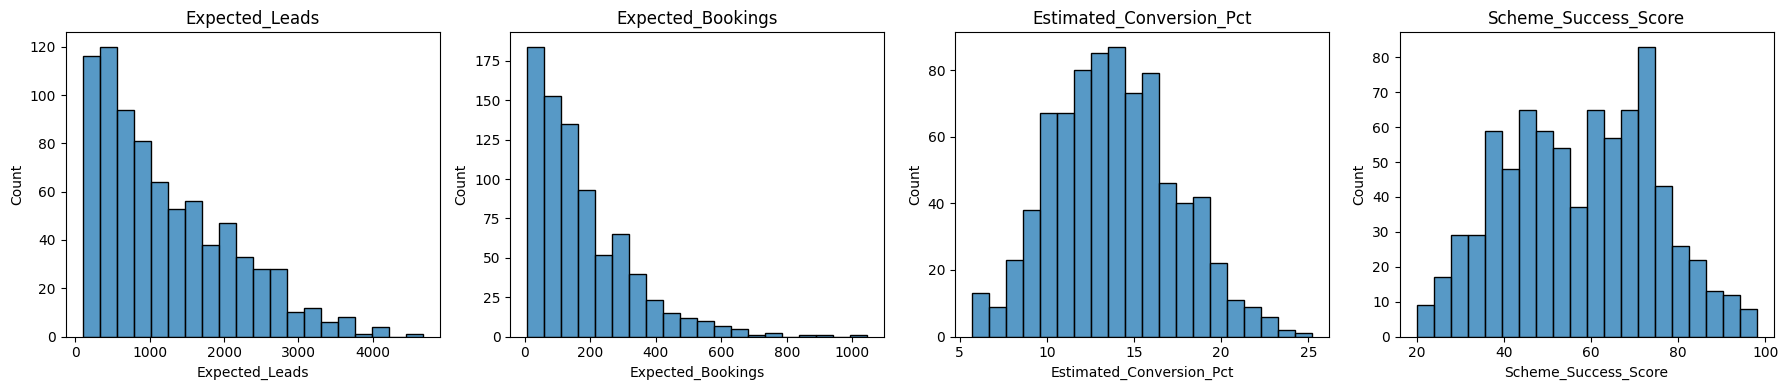

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, col in zip(axes, ["Expected_Leads", "Expected_Bookings", "Estimated_Conversion_Pct", "Scheme_Success_Score"]):
    sns.histplot(df[col], bins=20, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [4]:
df.corr(numeric_only=True)[["Expected_Leads","Expected_Bookings","Estimated_Conversion_Pct","Scheme_Success_Score"]]


,Expected_Leads,Expected_Bookings,Estimated_Conversion_Pct,Scheme_Success_Score
Plot_Size_SqFt,-0.040476,-0.026318,0.030645,0.019392
Price_INR,-0.033774,-0.041916,-0.058876,-0.028604
Monthly_EMI_INR,-0.033859,-0.041993,-0.058868,-0.028633
Distance_from_Metro_km,-0.264508,-0.387027,-0.518377,-0.437009
Advertising_Budget_INR,0.914441,0.767853,0.002404,0.532892
Expected_Leads,1.000000,0.926944,0.185902,0.653219
Expected_Bookings,0.926944,1.000000,0.469749,0.761300
Estimated_Conversion_Pct,0.185902,0.469749,1.000000,0.730691
Scheme_Success_Score,0.653219,0.761300,0.730691,1.000000


all 4 targets move together pretty closely (makes sense - more leads leads to
more bookings, better conversion, and a higher success score). Distance from metro
and advertising budget look like they matter most from the raw correlations, checking
that properly once the model is trained.

---

# Part 1 - Multi-output Regression

In [5]:
input_features = ["Location", "Plot_Size_SqFt", "Price_INR", "Monthly_EMI_INR",
                   "Park", "Clubhouse", "Distance_from_Metro_km", "Advertising_Budget_INR"]
target_cols = ["Expected_Leads", "Expected_Bookings", "Estimated_Conversion_Pct", "Scheme_Success_Score"]

X = df[input_features].copy()
y = df[target_cols].copy()

X = pd.get_dummies(X, columns=["Location", "Park", "Clubhouse"], drop_first=True)
print(X.shape, y.shape)
X.head()


(800, 18) (800, 4)


,Plot_Size_SqFt,Price_INR,Monthly_EMI_INR,Distance_from_Metro_km,Advertising_Budget_INR,Location_Bengaluru (East),Location_Bengaluru (North),Location_Chennai (OMR/Guduvanchery),Location_Delhi (Outer/Bawana),Location_Faridabad (Neharpar),Location_Greater Noida,Location_Gurugram (SPR/Sohna),Location_Hyderabad (Tellapur/Kollur),Location_Kolkata (New Town/Rajarhat),Location_Pune (Hinjewadi/Wakad),Location_Pune (Wagholi/Kharadi),Park_Yes,Clubhouse_Yes
0,800,1320000,9200,3.9,1500000,False,False,False,True,False,False,False,False,False,False,False,True,False
1,1800,8270000,57400,16.2,1500000,False,False,False,False,False,False,True,False,False,False,False,True,True
2,1500,3030000,21000,5.5,750000,False,False,False,False,False,False,False,False,True,False,False,True,False
3,1000,6360000,44200,23.9,1000000,False,True,False,False,False,False,False,False,False,False,False,True,False
4,2400,8150000,56600,23.4,1000000,False,False,False,False,False,True,False,False,False,False,False,False,False


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape


(640, 18)

### PCA check

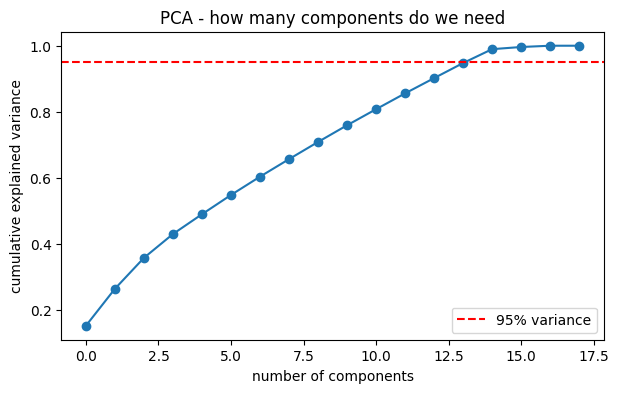

components needed for 95% variance: 15


In [7]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

plt.figure(figsize=(7,4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("number of components")
plt.ylabel("cumulative explained variance")
plt.legend()
plt.title("PCA - how many components do we need")
plt.show()

n_components_95 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1
print("components needed for 95% variance:", n_components_95)


In [8]:
pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


### baseline models

Random Forest and Linear Regression handle multiple output columns natively.
Gradient Boosting doesn't, so it needs to be wrapped with MultiOutputRegressor
(basically just trains one GB model per target behind the scenes).

In [9]:
def evaluate_multi(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    per_target_r2 = r2_score(y_te, pred, multioutput="raw_values")
    avg_r2 = r2_score(y_te, pred, multioutput="uniform_average")
    mae = mean_absolute_error(y_te, pred, multioutput="uniform_average")
    print(f"{name}: avg R2={avg_r2:.3f}  avg MAE={mae:.2f}")
    for col, r2 in zip(target_cols, per_target_r2):
        print(f"    {col}: R2={r2:.3f}")
    return {"model": model, "avg_r2": avg_r2, "mae": mae, "per_target_r2": per_target_r2}

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": MultiOutputRegressor(GradientBoostingRegressor(n_estimators=200, random_state=42)),
}

print("---without PCA---")
results_no_pca = {}
for name, model in models.items():
    results_no_pca[name] = evaluate_multi(model, X_train_scaled, X_test_scaled, y_train, y_test, name)


---without PCA---
Linear Regression: avg R2=0.670  avg MAE=74.39
    Expected_Leads: R2=0.885
    Expected_Bookings: R2=0.735
    Estimated_Conversion_Pct: R2=0.366
    Scheme_Success_Score: R2=0.696


Random Forest: avg R2=0.649  avg MAE=59.18
    Expected_Leads: R2=0.916
    Expected_Bookings: R2=0.805
    Estimated_Conversion_Pct: R2=0.263
    Scheme_Success_Score: R2=0.610


Gradient Boosting: avg R2=0.738  avg MAE=56.28
    Expected_Leads: R2=0.922
    Expected_Bookings: R2=0.870
    Estimated_Conversion_Pct: R2=0.412
    Scheme_Success_Score: R2=0.748


In [10]:
print("---with PCA---")
results_pca = {}
for name, model in models.items():
    results_pca[name] = evaluate_multi(model, X_train_pca, X_test_pca, y_train, y_test, name)


---with PCA---
Linear Regression: avg R2=0.674  avg MAE=73.87
    Expected_Leads: R2=0.884
    Expected_Bookings: R2=0.735
    Estimated_Conversion_Pct: R2=0.373
    Scheme_Success_Score: R2=0.702


Random Forest: avg R2=0.578  avg MAE=75.62
    Expected_Leads: R2=0.867
    Expected_Bookings: R2=0.717
    Estimated_Conversion_Pct: R2=0.163
    Scheme_Success_Score: R2=0.564


Gradient Boosting: avg R2=0.661  avg MAE=67.51
    Expected_Leads: R2=0.876
    Expected_Bookings: R2=0.793
    Estimated_Conversion_Pct: R2=0.278
    Scheme_Success_Score: R2=0.698


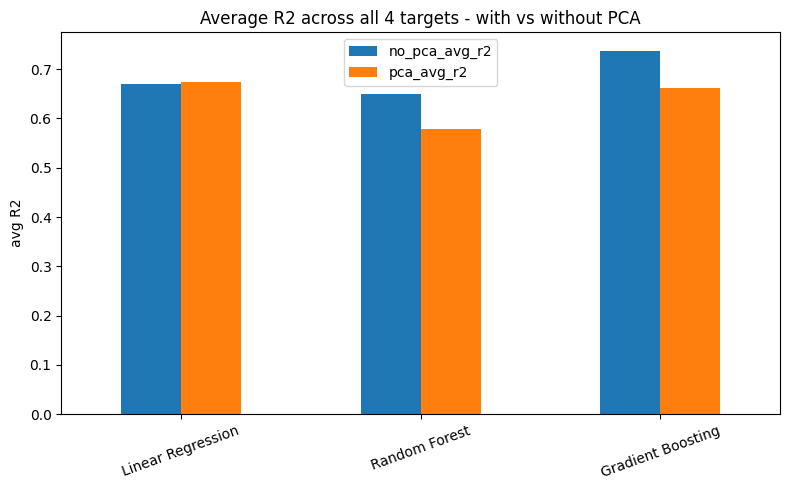

,no_pca_avg_r2,pca_avg_r2
Linear Regression,0.670347,0.673558
Random Forest,0.648768,0.577626
Gradient Boosting,0.737921,0.661485


In [11]:
compare_df = pd.DataFrame({
    "no_pca_avg_r2": {k: v["avg_r2"] for k, v in results_no_pca.items()},
    "pca_avg_r2": {k: v["avg_r2"] for k, v in results_pca.items()},
})
compare_df.plot(kind="bar", figsize=(8,5))
plt.title("Average R2 across all 4 targets - with vs without PCA")
plt.ylabel("avg R2")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
compare_df


### GridSearchCV tuning

tuning the Random Forest since it handles multi-output natively and doesn't need the wrapper class

In [12]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=5, scoring="r2", n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print("best params:", rf_grid.best_params_)
print("best cv avg r2:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_
tuned_result = evaluate_multi(best_rf, X_train_scaled, X_test_scaled, y_train, y_test, "Tuned Random Forest")


best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
best cv avg r2: 0.650079129393292


Tuned Random Forest: avg R2=0.648  avg MAE=58.97
    Expected_Leads: R2=0.917
    Expected_Bookings: R2=0.801
    Estimated_Conversion_Pct: R2=0.276
    Scheme_Success_Score: R2=0.599


In [13]:
gb_param_grid = {
    "estimator__n_estimators": [100, 200],
    "estimator__learning_rate": [0.05, 0.1],
    "estimator__max_depth": [2, 3],
}

gb_grid = GridSearchCV(
    MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
    gb_param_grid, cv=5, scoring="r2", n_jobs=-1
)
gb_grid.fit(X_train_scaled, y_train)

print("best params:", gb_grid.best_params_)
print("best cv avg r2:", gb_grid.best_score_)

best_gb = gb_grid.best_estimator_
gb_tuned_result = evaluate_multi(best_gb, X_train_scaled, X_test_scaled, y_train, y_test, "Tuned Gradient Boosting")


best params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 2, 'estimator__n_estimators': 200}
best cv avg r2: 0.7245759780241036


Tuned Gradient Boosting: avg R2=0.735  avg MAE=54.89
    Expected_Leads: R2=0.928
    Expected_Bookings: R2=0.845
    Estimated_Conversion_Pct: R2=0.412
    Scheme_Success_Score: R2=0.756


In [14]:
final_results = {
    "Linear Regression": results_no_pca["Linear Regression"],
    "Tuned Random Forest": tuned_result,
    "Tuned Gradient Boosting": gb_tuned_result,
}
final_df = pd.DataFrame({k: {"avg_r2": v["avg_r2"], "mae": v["mae"]} for k, v in final_results.items()}).T
final_df = final_df.sort_values("avg_r2", ascending=False)
final_df


,avg_r2,mae
Tuned Gradient Boosting,0.735019,54.889945
Linear Regression,0.670347,74.391561
Tuned Random Forest,0.648062,58.965006


### best model - predicted vs actual, per target

best model: Tuned Gradient Boosting


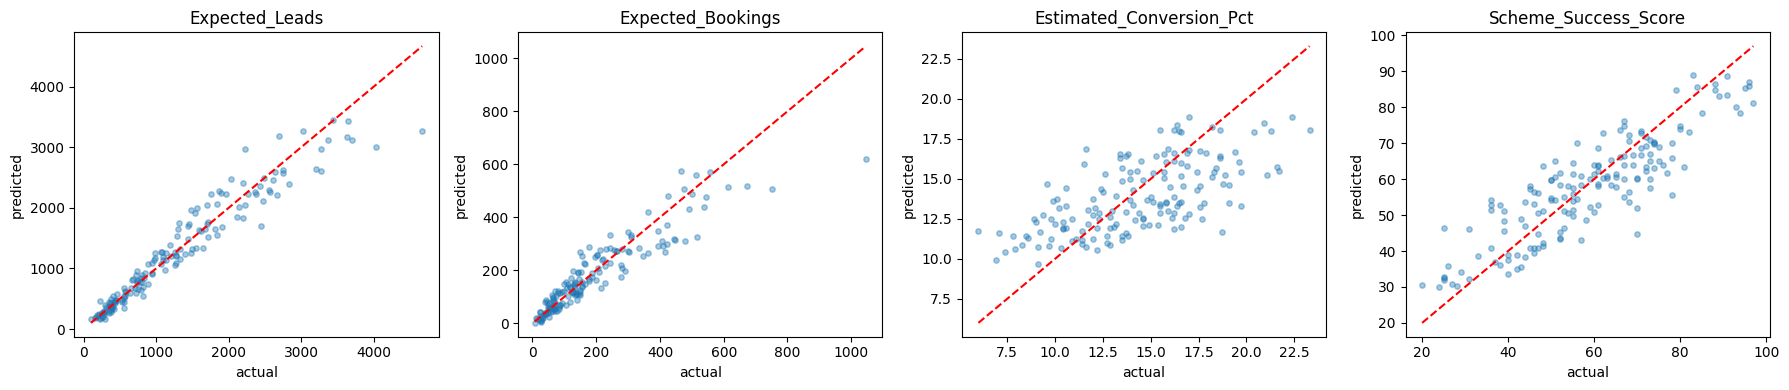

In [15]:
best_name = final_df.index[0]
best_model = final_results[best_name]["model"]
print("best model:", best_name)

pred = best_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, col, i in zip(axes, target_cols, range(4)):
    ax.scatter(y_test[col], pred[:, i], alpha=0.4, s=15)
    lims = [y_test[col].min(), y_test[col].max()]
    ax.plot(lims, lims, "r--")
    ax.set_title(col)
    ax.set_xlabel("actual")
    ax.set_ylabel("predicted")
plt.tight_layout()
plt.show()


In [16]:
import joblib

joblib.dump(best_model, "../models/scheme_multi_output_model.pkl")
joblib.dump(scaler, "../models/scheme_reg_scaler.pkl")
joblib.dump(list(X.columns), "../models/scheme_reg_columns.pkl")
joblib.dump(target_cols, "../models/scheme_reg_targets.pkl")
print("saved:", best_name)


saved: Tuned Gradient Boosting


---

# Part 2 - Classification (Demand_Level)

Same real inputs as above, predicting the HIGH/MEDIUM/LOW category directly instead
of going through the regression outputs. Not using Scheme_Success_Score as a feature -
checked earlier and Demand_Level is literally just binned straight from the score
(LOW = 20-49, MEDIUM = 50-74, HIGH = 75-98), so using it would be a 100% accuracy cheat,
not a real model.

In [17]:
Xc = df[input_features].copy()
yc = df["Demand_Level"].copy()

Xc = pd.get_dummies(Xc, columns=["Location", "Park", "Clubhouse"], drop_first=True)
yc.value_counts()


Demand_Level
MEDIUM    394
LOW       282
HIGH      124
Name: count, dtype: int64

In [18]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)

clf_scaler = MinMaxScaler()
Xc_train_scaled = clf_scaler.fit_transform(Xc_train)
Xc_test_scaled = clf_scaler.transform(Xc_test)


In [19]:
def evaluate_clf(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    acc = accuracy_score(y_te, pred)
    print(f"{name}: accuracy={acc:.3f}")
    return {"model": model, "acc": acc, "pred": pred}

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
}

clf_results = {}
for name, model in clf_models.items():
    clf_results[name] = evaluate_clf(model, Xc_train_scaled, Xc_test_scaled, yc_train, yc_test, name)


Logistic Regression: accuracy=0.719


Random Forest: accuracy=0.719


Gradient Boosting: accuracy=0.681


### GridSearchCV on the Random Forest classifier

In [20]:
rf_clf_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
}

rf_clf_search = GridSearchCV(RandomForestClassifier(random_state=42), rf_clf_grid, cv=5, scoring="accuracy", n_jobs=-1)
rf_clf_search.fit(Xc_train_scaled, yc_train)
print("best params:", rf_clf_search.best_params_)
print("best cv accuracy:", rf_clf_search.best_score_)

best_rf_clf = rf_clf_search.best_estimator_
tuned_clf_result = evaluate_clf(best_rf_clf, Xc_train_scaled, Xc_test_scaled, yc_train, yc_test, "Tuned Random Forest")


best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
best cv accuracy: 0.7484375


Tuned Random Forest: accuracy=0.731


In [21]:
clf_final = {**clf_results, "Tuned Random Forest": tuned_clf_result}
clf_summary = pd.DataFrame({k: {"accuracy": v["acc"]} for k, v in clf_final.items()}).T
clf_summary = clf_summary.sort_values("accuracy", ascending=False)
clf_summary


,accuracy
Tuned Random Forest,0.73125
Logistic Regression,0.71875
Random Forest,0.71875
Gradient Boosting,0.68125


best classifier: Tuned Random Forest

              precision    recall  f1-score   support

        HIGH       0.80      0.64      0.71        25
         LOW       0.74      0.71      0.73        56
      MEDIUM       0.71      0.77      0.74        79

    accuracy                           0.73       160
   macro avg       0.75      0.71      0.73       160
weighted avg       0.73      0.73      0.73       160



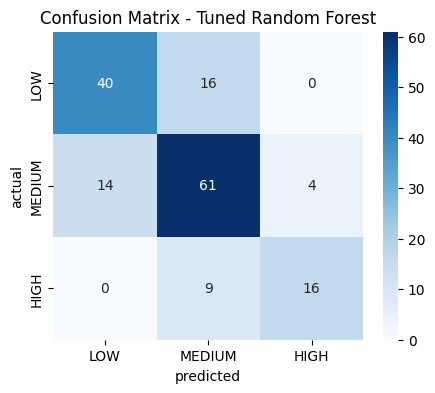

In [22]:
best_clf_name = clf_summary.index[0]
best_clf_model = clf_final[best_clf_name]["model"]
pred = clf_final[best_clf_name]["pred"]

print("best classifier:", best_clf_name)
print()
print(classification_report(yc_test, pred))

cm = confusion_matrix(yc_test, pred, labels=["LOW","MEDIUM","HIGH"])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["LOW","MEDIUM","HIGH"], yticklabels=["LOW","MEDIUM","HIGH"])
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title(f"Confusion Matrix - {best_clf_name}")
plt.show()


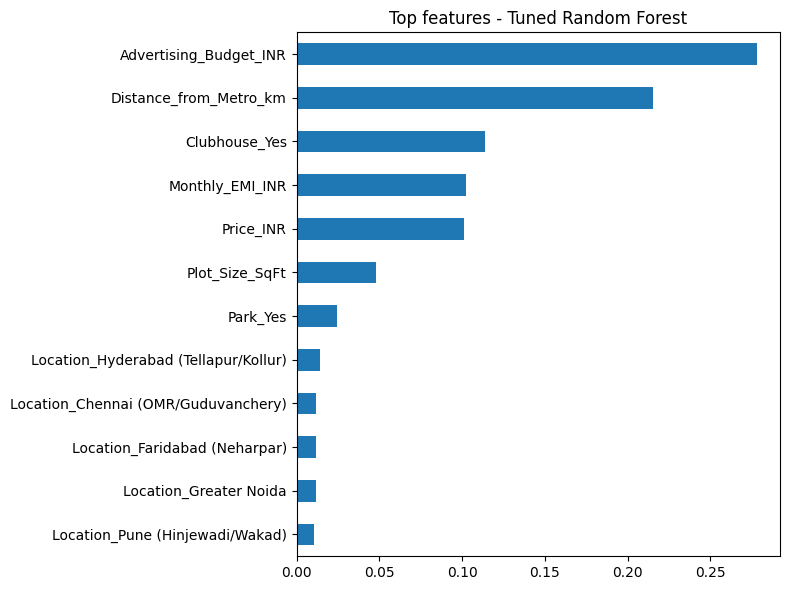

In [23]:
if hasattr(best_clf_model, "feature_importances_"):
    importances = pd.Series(best_clf_model.feature_importances_, index=Xc.columns)
    importances.sort_values(ascending=False).head(12).sort_values().plot(kind="barh", figsize=(8,6))
    plt.title(f"Top features - {best_clf_name}")
    plt.tight_layout()
    plt.show()


In [24]:
joblib.dump(best_clf_model, "../models/scheme_demand_classifier.pkl")
joblib.dump(clf_scaler, "../models/scheme_demand_scaler.pkl")
joblib.dump(list(Xc.columns), "../models/scheme_demand_columns.pkl")
print("saved:", best_clf_name)


saved: Tuned Random Forest


## notes

- this version only uses real "before you launch it" inputs - no more leads/bookings/
  conversion as features anywhere, since now they're part of what we're predicting
- Random Forest handles predicting 4 numbers at once natively, Gradient Boosting needed
  the MultiOutputRegressor wrapper (it only outputs one number by default)
- Estimated_Conversion_Pct was the hardest of the 4 to predict well - makes sense,
  it's a ratio and probably has more noise in it than the raw counts
- PCA still doesn't really help - not enough columns to have much redundant dimensionality
- for the classifier, distance from metro and advertising budget came out as the
  strongest predictors of demand level, matches what the correlations showed earlier
